**Install Libraries and Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries ready!")

Libraries ready!


**Load the dataset**

In [2]:
df = pd.read_csv('USvideos.csv', encoding='latin-1')

print("Shape:", df.shape)
print("\n--- First 5 rows ---")
df.head()

Shape: (40949, 16)

--- First 5 rows ---


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


**Check data types and missing values**

In [3]:
print("--- Column info ---")
print(df.info())

print("\n--- Missing values ---")
print(df.isnull().sum())

--- Column info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-

**Load category names from JSON and map to dataset**

In [4]:
import json

#Load the JSON file
with open('US_category_id.json', 'r') as f:
    cat_data = json.load(f)

#Build a dictionary: {category_id: category_name}
category_map = {int(item['id']): item['snippet']['title']
                for item in cat_data['items']}

print("Category mapping:")
for k, v in category_map.items():
    print(f"  {k}: {v}")

Category mapping:
  1: Film & Animation
  2: Autos & Vehicles
  10: Music
  15: Pets & Animals
  17: Sports
  18: Short Movies
  19: Travel & Events
  20: Gaming
  21: Videoblogging
  22: People & Blogs
  23: Comedy
  24: Entertainment
  25: News & Politics
  26: Howto & Style
  27: Education
  28: Science & Technology
  29: Nonprofits & Activism
  30: Movies
  31: Anime/Animation
  32: Action/Adventure
  33: Classics
  34: Comedy
  35: Documentary
  36: Drama
  37: Family
  38: Foreign
  39: Horror
  40: Sci-Fi/Fantasy
  41: Thriller
  42: Shorts
  43: Shows
  44: Trailers


**Clean and engineer features**

In [5]:
#Map category names
df['category'] = df['category_id'].map(category_map)

#Convert trending_date to datetime
#Format is YY.DD.MM e.g. 17.14.11 = 2017, 14th day, 11th month
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')

#Convert publish_time to datetime
df['publish_time'] = pd.to_datetime(df['publish_time'])

#Extract useful time features
df['publish_hour'] = df['publish_time'].dt.hour
df['publish_day'] = df['publish_time'].dt.day_name()
df['publish_month'] = df['publish_time'].dt.month

#Calculate days it took to trend after publishing
df['days_to_trend'] = (df['trending_date'] - df['publish_time'].dt.tz_localize(None)).dt.days

#Create engagement rate features
#Like rate = likes / views
#Comment rate = comments / views
#Dislike rate = dislikes / views
df['like_rate']    = df['likes'] / df['views']
df['dislike_rate'] = df['dislikes'] / df['views']
df['comment_rate'] = df['comment_count'] / df['views']

#Drop rows where days_to_trend is negative (data inconsistency)
df = df[df['days_to_trend'] >= 0]

print(f"Dataset shape after cleaning: {df.shape}")
print(f"\nNew columns added:")
print(df[['category','publish_hour','publish_day','days_to_trend',
          'like_rate','dislike_rate','comment_rate']].head())

Dataset shape after cleaning: (40829, 24)

New columns added:
         category  publish_hour publish_day  days_to_trend  like_rate  \
0  People & Blogs            17      Monday              0   0.076869   
1   Entertainment             7      Monday              0   0.040179   
2          Comedy            19      Sunday              1   0.045758   
3   Entertainment            11      Monday              0   0.029641   
4   Entertainment            18      Sunday              1   0.063097   

   dislike_rate  comment_rate  
0      0.003963      0.021318  
1      0.002541      0.005252  
2      0.001673      0.002563  
3      0.001941      0.006253  
4      0.000949      0.008359  


**Basic stats on key metrics**

In [6]:
print("--- Views, Likes, Comments summary ---")
print(df[['views','likes','dislikes','comment_count',
          'like_rate','days_to_trend']].describe().round(2))

--- Views, Likes, Comments summary ---
              views       likes    dislikes  comment_count  like_rate  \
count  4.082900e+04    40829.00    40829.00       40829.00   40829.00   
mean   2.366565e+06    74422.42     3719.82        8464.09       0.03   
std    7.404112e+06   229189.15    29071.69       37482.80       0.03   
min    5.490000e+02        0.00        0.00           0.00       0.00   
25%    2.439090e+05     5451.00      203.00         616.00       0.01   
50%    6.843740e+05    18171.00      633.00        1861.00       0.03   
75%    1.827757e+06    55540.00     1941.00        5765.00       0.05   
max    2.252119e+08  5613827.00  1674420.00     1361580.00       0.27   

       days_to_trend  
count       40829.00  
mean           15.86  
std           146.23  
min             0.00  
25%             2.00  
50%             4.00  
75%             8.00  
max          4214.00  


**Views distribution and top categories by video count**

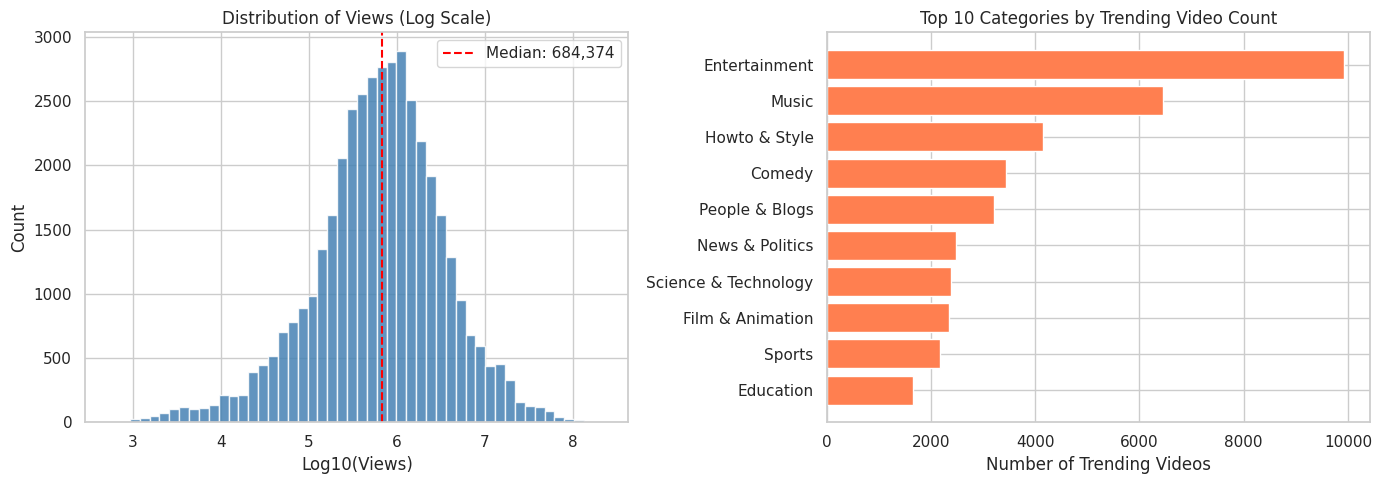

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Plot 1: Views distribution (log scale because of extreme skew)
axes[0].hist(np.log10(df['views'] + 1), bins=50,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Log10(Views)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Views (Log Scale)')
axes[0].axvline(np.log10(df['views'].median()), color='red',
                linestyle='--', label=f'Median: {df["views"].median():,.0f}')
axes[0].legend()

#Plot 2: Top 10 categories by video count
top_cats = df['category'].value_counts().head(10)
axes[1].barh(top_cats.index, top_cats.values,
             color='coral', edgecolor='white')
axes[1].set_xlabel('Number of Trending Videos')
axes[1].set_title('Top 10 Categories by Trending Video Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Average views, like rate and days to trend per category**

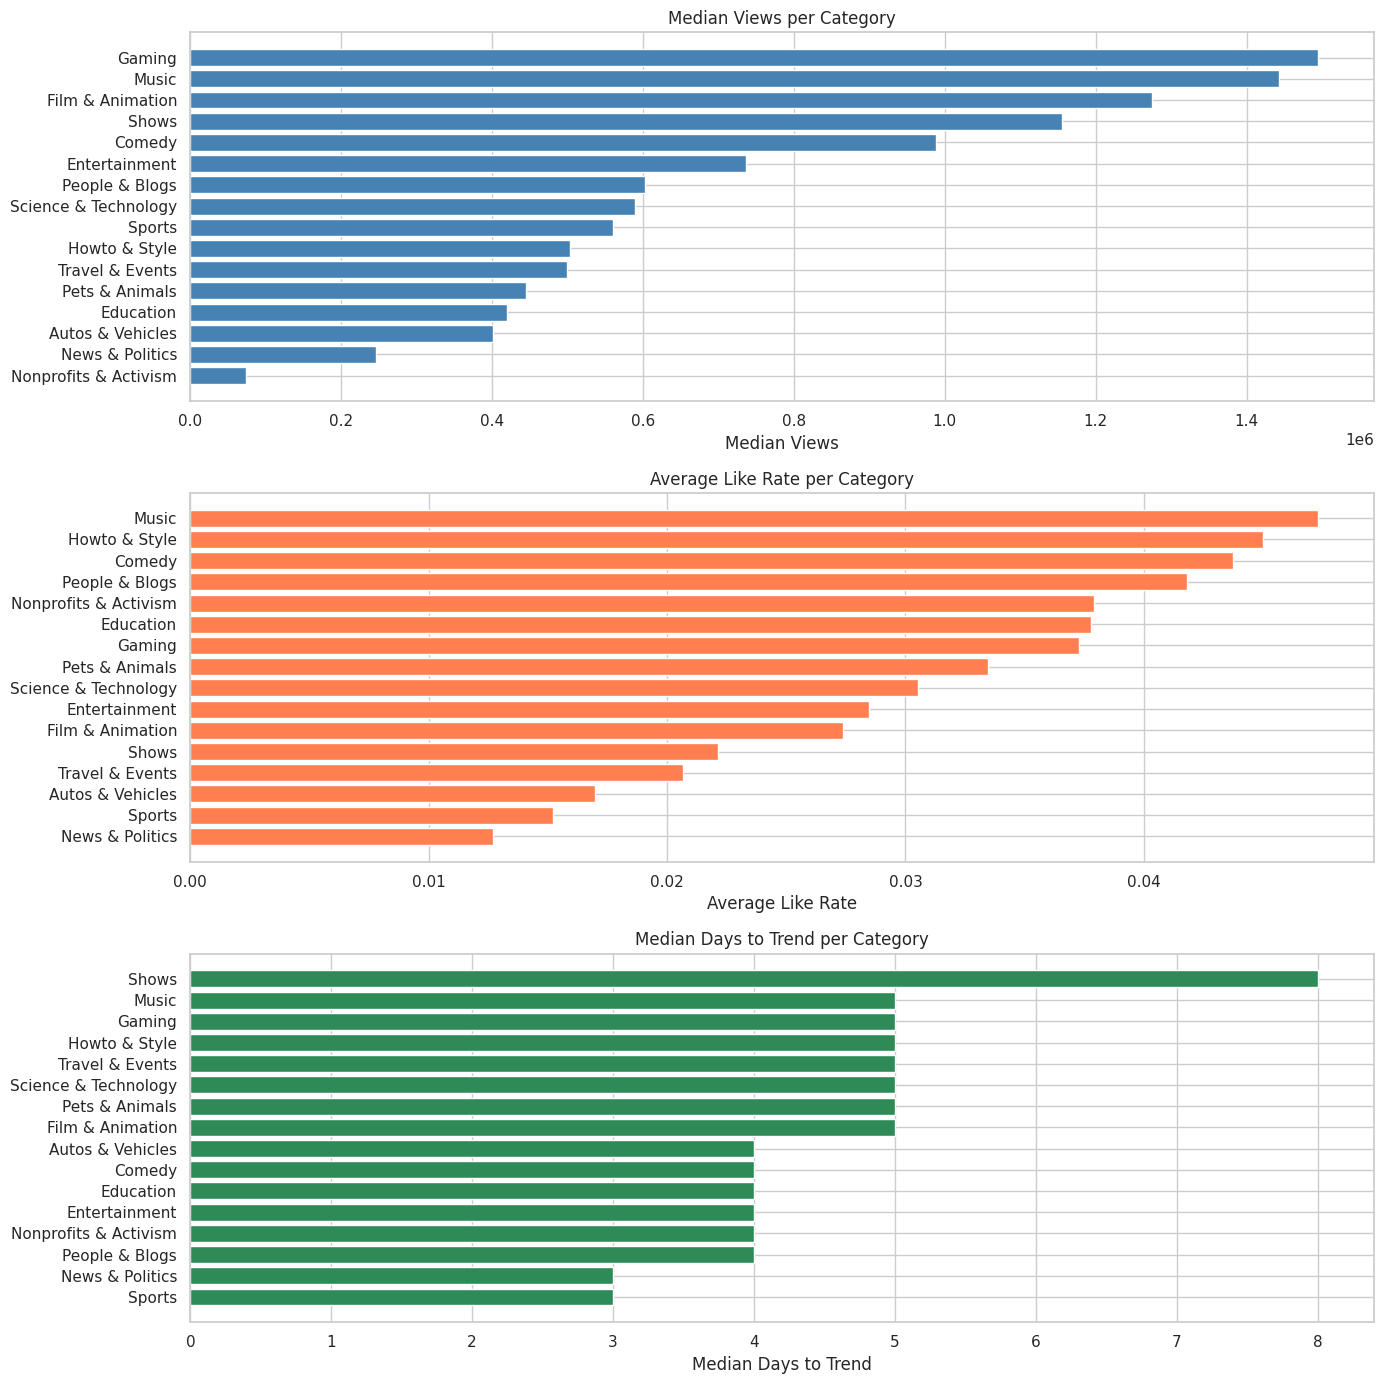

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

#Plot 1: Average views per category
cat_views = df.groupby('category')['views'].median().sort_values(ascending=False)
axes[0].barh(cat_views.index, cat_views.values,
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Median Views')
axes[0].set_title('Median Views per Category')
axes[0].invert_yaxis()

#Plot 2: Average like rate per category
cat_likes = df.groupby('category')['like_rate'].mean().sort_values(ascending=False)
axes[1].barh(cat_likes.index, cat_likes.values,
             color='coral', edgecolor='white')
axes[1].set_xlabel('Average Like Rate')
axes[1].set_title('Average Like Rate per Category')
axes[1].invert_yaxis()

#Plot 3: Average days to trend per category
cat_days = df.groupby('category')['days_to_trend'].median().sort_values(ascending=False)
axes[2].barh(cat_days.index, cat_days.values,
             color='seagreen', edgecolor='white')
axes[2].set_xlabel('Median Days to Trend')
axes[2].set_title('Median Days to Trend per Category')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

**Publishing patterns - best time and day to publish**

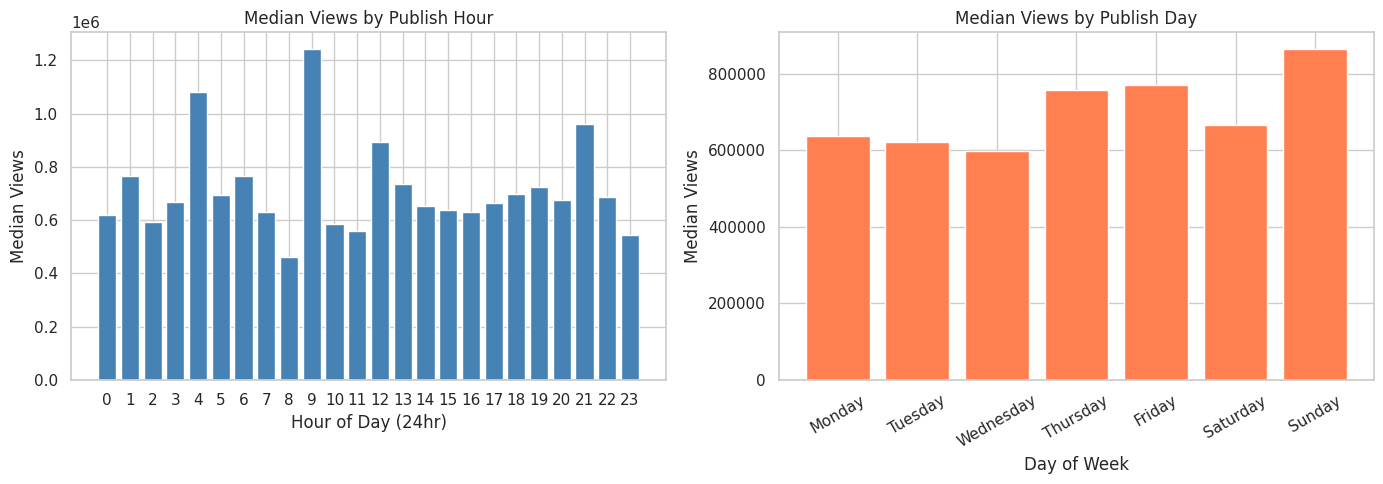

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Plot 1: Views by publish hour
hour_views = df.groupby('publish_hour')['views'].median()
axes[0].bar(hour_views.index, hour_views.values,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Hour of Day (24hr)')
axes[0].set_ylabel('Median Views')
axes[0].set_title('Median Views by Publish Hour')
axes[0].set_xticks(range(0, 24))

#Plot 2: Views by publish day
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_views = df.groupby('publish_day')['views'].median().reindex(day_order)
axes[1].bar(day_views.index, day_views.values,
            color='coral', edgecolor='white')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Median Views')
axes[1].set_title('Median Views by Publish Day')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Engagement analysis - correlation between metrics**

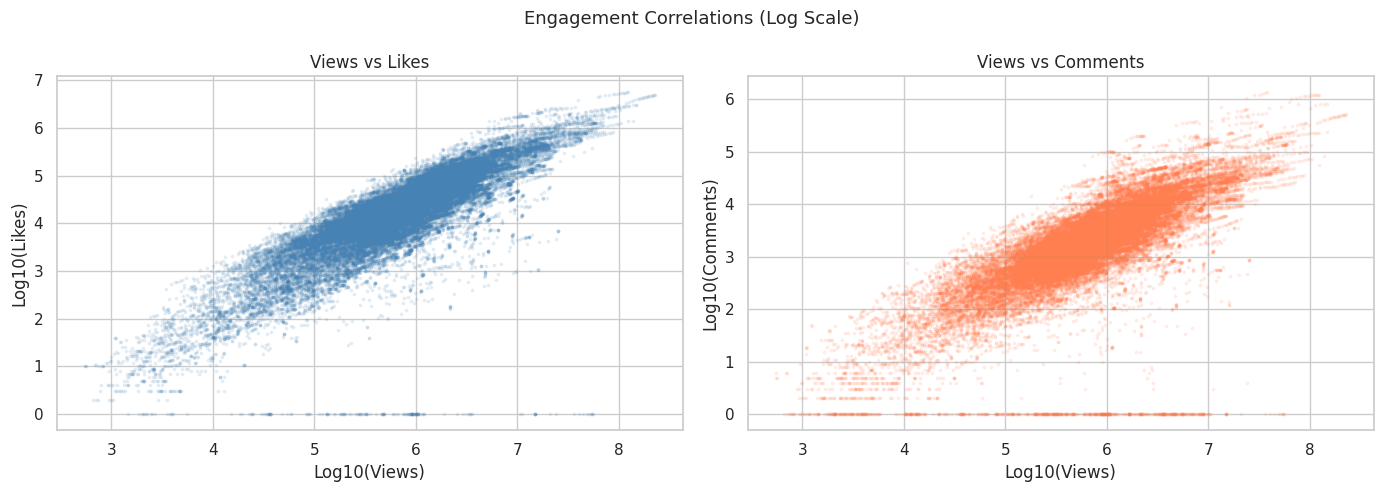

Correlation with Views:
  Likes:    0.849
  Comments: 0.618
  Dislikes: 0.472


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Plot 1: Views vs Likes (log scale)
axes[0].scatter(np.log10(df['views'] + 1),
                np.log10(df['likes'] + 1),
                alpha=0.1, s=3, color='steelblue')
axes[0].set_xlabel('Log10(Views)')
axes[0].set_ylabel('Log10(Likes)')
axes[0].set_title('Views vs Likes')

#Plot 2: Views vs Comments (log scale)
axes[1].scatter(np.log10(df['views'] + 1),
                np.log10(df['comment_count'] + 1),
                alpha=0.1, s=3, color='coral')
axes[1].set_xlabel('Log10(Views)')
axes[1].set_ylabel('Log10(Comments)')
axes[1].set_title('Views vs Comments')

plt.suptitle('Engagement Correlations (Log Scale)', fontsize=13)
plt.tight_layout()
plt.show()

#Print correlation values
print("Correlation with Views:")
print(f"  Likes:    {df['views'].corr(df['likes']):.3f}")
print(f"  Comments: {df['views'].corr(df['comment_count']):.3f}")
print(f"  Dislikes: {df['views'].corr(df['dislikes']):.3f}")

**Top 10 most viewed channels and viral video analysis**

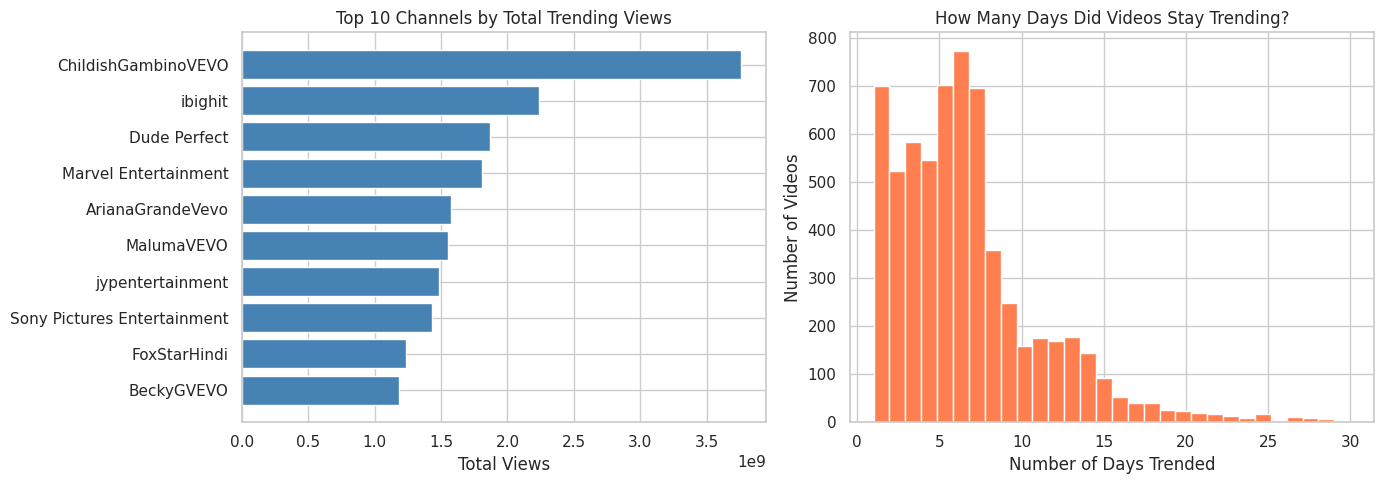

Videos that trended only 1 day:  699
Videos that trended 5+ days:     3983
Videos that trended 10+ days:    1205
Max days a video trended:         30


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Plot 1: Top 10 channels by total trending views
top_channels = (df.groupby('channel_title')['views']
                .sum()
                .sort_values(ascending=False)
                .head(10))
axes[0].barh(top_channels.index, top_channels.values,
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Total Views')
axes[0].set_title('Top 10 Channels by Total Trending Views')
axes[0].invert_yaxis()

#Plot 2: Videos that trended multiple times
trend_counts = df.groupby('video_id')['trending_date'].count()
axes[1].hist(trend_counts.values, bins=30,
             color='coral', edgecolor='white')
axes[1].set_xlabel('Number of Days Trended')
axes[1].set_ylabel('Number of Videos')
axes[1].set_title('How Many Days Did Videos Stay Trending?')

plt.tight_layout()
plt.show()

print(f"Videos that trended only 1 day:  {(trend_counts==1).sum()}")
print(f"Videos that trended 5+ days:     {(trend_counts>=5).sum()}")
print(f"Videos that trended 10+ days:    {(trend_counts>=10).sum()}")
print(f"Max days a video trended:         {trend_counts.max()}")

**Final summary — engagement score and business insights**

In [12]:
#Create a composite engagement score
#Weighted combination of like rate, comment rate, view volume
df['engagement_score'] = (
    df['like_rate'] * 0.5 +
    df['comment_rate'] * 0.3 +
    (np.log10(df['views'] + 1) / 10) * 0.2
)

#Top 10 most engaging videos overall
top_engaging = (df[['title', 'channel_title', 'category',
                     'views', 'like_rate', 'comment_rate',
                     'engagement_score', 'days_to_trend']]
                .sort_values('engagement_score', ascending=False)
                .drop_duplicates(subset='title')
                .head(10))

print("=== TOP 10 MOST ENGAGING TRENDING VIDEOS ===\n")
for _, row in top_engaging.iterrows():
    print(f"Title:    {row['title'][:60]}")
    print(f"Channel:  {row['channel_title']}")
    print(f"Category: {row['category']}")
    print(f"Views:    {row['views']:,} | Like Rate: {row['like_rate']:.3f} | Days to Trend: {row['days_to_trend']}")
    print()

#Category engagement summary
print("\n=== CATEGORY ENGAGEMENT SUMMARY ===\n")
cat_summary = df.groupby('category').agg(
    total_videos    = ('video_id', 'count'),
    median_views    = ('views', 'median'),
    avg_like_rate   = ('like_rate', 'mean'),
    avg_days_trend  = ('days_to_trend', 'median'),
    avg_eng_score   = ('engagement_score', 'mean')
).round(3).sort_values('avg_eng_score', ascending=False)

print(cat_summary.to_string())

=== TOP 10 MOST ENGAGING TRENDING VIDEOS ===

Title:    j-hope 'Airplane' MV
Channel:  ibighit
Category: Music
Views:    5,275,672 | Like Rate: 0.266 | Days to Trend: 0

Title:    BTS (ë°©íìëë¨) 'FAKE LOVE' Official MV (Extended ver.
Channel:  ibighit
Category: Music
Views:    5,884,233 | Like Rate: 0.244 | Days to Trend: 0

Title:    Louis Tomlinson - Miss You (Official Video)
Channel:  LouisTomlinsonVEVO
Category: Music
Views:    985,998 | Like Rate: 0.245 | Days to Trend: 0

Title:    BTS (ë°©íìëë¨) 'MIC Drop (Steve Aoki Remix)' Official
Channel:  ibighit
Category: Music
Views:    3,483,755 | Like Rate: 0.227 | Days to Trend: 0

Title:    BTS (ë°©íìëë¨) 'Euphoria : Theme of LOVE YOURSELF èµ·
Channel:  ibighit
Category: Music
Views:    7,518,332 | Like Rate: 0.209 | Days to Trend: 0

Title:    CRISTIANO RONALDO E FRED, O GRANDE ENCONTRO
Channel:  Desimpedidos
Category: Sports
Views:    3,990,953 | Like Rate: 0.223 | Days to Trend: 1

Title:    j-hope 'Daydream (ë

**Business insights summary + save files**

In [14]:
print("=" * 62)
print("   YOUTUBE RETENTION ANALYSIS — BUSINESS SUMMARY")
print("=" * 62)

print("""
KEY FINDINGS:

1. BEST CATEGORY FOR VIEWS
   Gaming and Music get highest median views (1.4M+)
   when trending. Entertainment trends most frequently
   but with lower median views (736K).

2. BEST TIME TO PUBLISH
   Day:  Sunday drives highest median views (870K)
   Hour: 9am is the peak publish hour (1.25M median views)
   Recommendation: Publish Sunday at 9am for max reach.

3. ENGAGEMENT BY CATEGORY
   Music has highest engagement score (0.148) and
   like rate (4.7%). News & Politics has lowest like
   rate (1.3%) — audiences watch but don't engage.

4. TRENDING DURATION
   Most videos trend 5–7 days. 1,205 videos trended
   10+ days showing sustained audience retention.
   Sports and News trend fastest (3 days).

5. VIRAL CONTENT PATTERN
   BTS/ibighit dominates top engaging content with
   like rates of 20–26% — 8x the platform average.
   Dedicated fanbases drive disproportionate engagement.

6. LIKES ARE THE STRONGEST SIGNAL
   Correlation: Likes=0.849, Comments=0.618,
   Dislikes=0.472. Like rate is the best single
   metric to measure true audience engagement.
""")

print("=" * 62)
print("BUSINESS RECOMMENDATIONS:")
print("=" * 62)
print("""
  For YouTube Creators:
  - Publish on Sunday at 9am
  - Target Music or Gaming for highest view potential
  - Focus on like rate over raw views as success metric
  - Aim for 5+ trending days as retention benchmark

  For YouTube (Platform):
  - Promote Gaming content more — high views, underserved
  - News & Politics needs engagement features redesign
  - K-pop/fan communities are highest engagement drivers
  - Shows category takes longest to trend — needs boost
""")

#Save outputs
df[['video_id','title','channel_title','category','views',
    'likes','dislikes','comment_count','publish_hour',
    'publish_day','days_to_trend','like_rate',
    'comment_rate','engagement_score']].to_csv('youtube_analysis.csv', index=False)

cat_summary.to_csv('category_summary.csv')

print("Files saved:")
print("  youtube_analysis.csv  — full dataset with engineered features")
print("  category_summary.csv  — engagement metrics per category")

   YOUTUBE RETENTION ANALYSIS — BUSINESS SUMMARY

KEY FINDINGS:

1. BEST CATEGORY FOR VIEWS
   Gaming and Music get highest median views (1.4M+)
   when trending. Entertainment trends most frequently
   but with lower median views (736K).

2. BEST TIME TO PUBLISH
   Day:  Sunday drives highest median views (870K)
   Hour: 9am is the peak publish hour (1.25M median views)
   Recommendation: Publish Sunday at 9am for max reach.

3. ENGAGEMENT BY CATEGORY
   Music has highest engagement score (0.148) and
   like rate (4.7%). News & Politics has lowest like
   rate (1.3%) — audiences watch but don't engage.

4. TRENDING DURATION
   Most videos trend 5–7 days. 1,205 videos trended
   10+ days showing sustained audience retention.
   Sports and News trend fastest (3 days).

5. VIRAL CONTENT PATTERN
   BTS/ibighit dominates top engaging content with
   like rates of 20–26% — 8x the platform average.
   Dedicated fanbases drive disproportionate engagement.

6. LIKES ARE THE STRONGEST SIGNAL
  